In [1]:
from LoadData import *  
from YOLOv1 import *

S = (10,10)
C = 1
B = 2
IMG_SIZE = (448, 448)

X,Y = load_data(train_path, S=S, imgsize=IMG_SIZE, B=B, C=C)
# print(Y.shape)
# Convert to GPU and transpose X to channels-first (N, C, H, W) for our Conv implementation
X_transpose = to_gpu(X).transpose(0, 3, 1, 2)
Y_gpu = to_gpu(Y)

d:\Python\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


🚀 [Backend] Using CuPy (GPU Acceleration)
🚀 [Backend] Using CuPy (GPU Acceleration)
排序后的图像文件列表:
总共有 398 个图像文件


In [2]:
path = 'models/yolov1_shallow.npz'
cnn = CNN.load_model(path)

Loading model from models/yolov1_shallow.npz...
0.032640796019900546
Resuming training from epoch 167 with LR=1.729105667246016e-05
Model loaded successfully.


进行参数嫁接

In [3]:


layers = cnn.layers[:-6]
layer_left = [
            FC(output_size=4096),
            Activation('sigmoid'),
            FC(output_size=S[0]*S[1]*(B*5+C)),
            Activation('sigmoid'),
]
layers = layers + layer_left



In [4]:

path = 'models/yolov1_mask_dectection.npz'
# path = ""


yolo = None
import os
if os.path.exists(path):
    yolo = YOLOv1.load_model(path)
    if yolo is not None:
        yolo.explicit_init(Y_gpu, S, B, C)
        print("Model loaded successfully from", path)
        # yolo.unified_hyperparam(learning_rate=yolo.learning_rate, _Adam=False)
        # yolo.learning_rate = 0.01
        # yolo.lambda_coord = 5
        # yolo.lambda_size = 20
        # yolo.lambda_obj = 10
        # yolo.lambda_noobj = 0.5
        # print(yolo.isInBox)
    else:
        print("Model file exists but loading failed. Will create new model.")
        
if yolo is None:
    yolo = YOLOv1(
        layers=layers,
        learning_rate=0.0001,
        _Adam=True,
        Adam_beta1 = 0.7,
        Adam_beta2 = 0.95,
    )
    yolo.explicit_init(Y_gpu, S, B, C)
    print("New model created and initialized.")


# path = 'models/yolov1_mask_dectection_bad.npz'

yolo.learning_rate *= 0.87
yolo.lambda_obj = 6.0
yolo.lambda_size = 30
yolo._Adam = False
print(yolo._Adam)
print(yolo.learning_rate)
print(yolo.lambda_noobj,yolo.lambda_coord,yolo.lambda_obj,yolo.lambda_size)
yolo.train(X_transpose, Y_gpu, epochs=500, batch_size=20, save_path=path)

Loading model from models/yolov1_mask_dectection.npz...
0.03022842892768085
Model loaded successfully from models/yolov1_mask_dectection.npz
False
6.786982382632348e-05
0.5 5.0 6.0 30
Training with 186 samples, batch_size=20, num_batches=10
Epoch 180/680 Batch 0/10  cost: 1.128986
Epoch 180/680 Batch 2/10  cost: 1.886192
Epoch 180/680 Batch 4/10  cost: 1.289274
Epoch 180/680 Batch 6/10  cost: 1.174042
Epoch 180/680 Batch 8/10  cost: 1.187483
Cost after epoch 0: 1.369778
Model saved to models/yolov1_mask_dectection.npz
Epoch 181/680 Batch 0/10  cost: 1.523867
Epoch 181/680 Batch 2/10  cost: 1.401688
Epoch 181/680 Batch 4/10  cost: 1.312534
Epoch 181/680 Batch 6/10  cost: 1.248242
Epoch 181/680 Batch 8/10  cost: 1.648946
Cost after epoch 1: 1.336953
Model saved to models/yolov1_mask_dectection.npz
Epoch 182/680 Batch 0/10  cost: 1.622972
Epoch 182/680 Batch 2/10  cost: 1.566774
Epoch 182/680 Batch 4/10  cost: 1.025375
Epoch 182/680 Batch 6/10  cost: 2.021818
Epoch 182/680 Batch 8/10  cos

array([10.568365097045898, 2.568509340286255, 2.0889945030212402,
       1.8965963125228882, 1.8012304306030273, 1.6934680938720703,
       1.646141529083252, 1.6531260013580322, 1.5768208503723145,
       1.5266705751419067, 1.543582797050476, 1.5008622407913208,
       1.546302080154419, 1.4521751403808594, 1.4733494520187378,
       1.4968990087509155, 1.324410080909729, 1.3310046195983887,
       1.2079274654388428, 1.2153511047363281, 1.222529411315918,
       1.2315185070037842, 1.314995288848877, 1.1796619892120361,
       1.1934750080108643, 1.306630253791809, 1.3006919622421265,
       1.167478084564209, 1.1958009004592896, 1.2998151779174805,
       1.2492432594299316, 1.2522850036621094, 1.1368229389190674,
       1.1492021083831787, 1.093667984008789, 1.1601495742797852,
       1.1921228170394897, 1.1933481693267822, 1.0332483053207397,
       0.875984787940979, 0.8776344656944275, 0.900638997554779,
       0.9333378076553345, 1.009974718093872, 0.9587487578392029,
       0

In [5]:
from Display import display_image
X_test, Y_test = load_data(test_path, S=S, imgsize=IMG_SIZE, B=B, C=C)

排序后的图像文件列表:
总共有 102 个图像文件


In [6]:
def print_predictions(Y:np.ndarray,S, B, C):
    for i in range(S[0]):
        for j in range(S[1]):
            print(f"Grid cell ({i}, {j}):")
            print(f"Class probabilities: {Y[i, j, B*5:]}")
            for b in range(B):
                print(f"Box {b}:")
                print(Y[i,j, b*5:(b+1)*5])

def print_single_predictions(Y:np.ndarray,S, B, C):
    for i in range(S[0]):
        for j in range(S[1]):
            print(f"Grid cell ({i}, {j}):")
            print(f"Class probabilities: {Y[0, i, j, B*5:]}")
            for b in range(B):
                print(f"Box {b}:")
                print(Y[0, i, j, b*5:(b+1)*5])

Grid cell (0, 0):
Class probabilities: [0.1841758]
Box 0:
[0.80127376 0.8094892  0.35277656 0.5906214  0.00752634]
Box 1:
[0.25514823 0.33940908 0.7273909  0.4055148  0.00740539]
Grid cell (0, 1):
Class probabilities: [0.29907602]
Box 0:
[0.2830602  0.6885698  0.33380783 0.30631354 0.00875218]
Box 1:
[0.21732949 0.774716   0.18901914 0.45268634 0.0089118 ]
Grid cell (0, 2):
Class probabilities: [0.9557184]
Box 0:
[0.07412608 0.24333763 0.01818456 0.04125954 0.01151517]
Box 1:
[0.7087309  0.5502258  0.6147057  0.6549784  0.00819804]
Grid cell (0, 3):
Class probabilities: [0.3250687]
Box 0:
[0.45313612 0.37175068 0.74592775 0.43869555 0.00847022]
Box 1:
[0.6564388  0.74231285 0.26188383 0.5197298  0.00889584]
Grid cell (0, 4):
Class probabilities: [0.9026474]
Box 0:
[0.04602304 0.49867204 0.02159131 0.08774279 0.00873611]
Box 1:
[0.4058821  0.38164446 0.35455173 0.3114586  0.00771604]
Grid cell (0, 5):
Class probabilities: [0.9395631]
Box 0:
[0.09548844 0.5340872  0.02258316 0.05097676 0

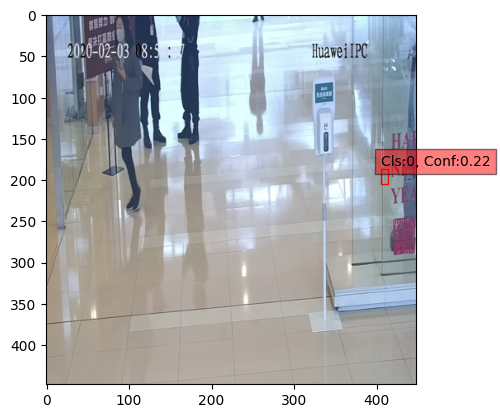

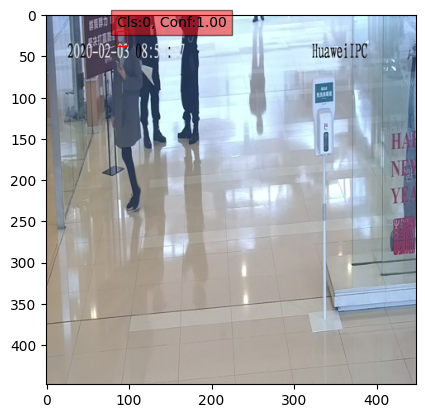

In [7]:
yolo.outputshape = Y_test.shape
idx = 100
# print(yolo.evaluate(X_test.transpose(0,3,1,2), Y_test))
# Y_pred = yolo.predict(X_test[idx:idx+1].transpose(0,3,1,2),batch_size=2)# 保证是4维
# display_image(X_test[idx], Y_pred)
# display_image(X_test[idx], Y_test[idx])

Y_pred = yolo.predict(X_transpose[idx:idx+1],batch_size=2)
print_single_predictions(Y_pred, S, B, C)
display_image(to_cpu(X[idx]), to_cpu(Y_pred))
display_image(to_cpu(X[idx]), to_cpu(Y_gpu[idx]))
